# PCA Supervised Forecasting Baseline

This notebook implements the first supervised forecasting experiment for **Topological Compression of Prediction Market Belief Dynamics**.

Goal: for each observed market-time pair `(i, t)`, predict the final binary resolution `Y_i` using:

- baseline: `p_hat = p_i,t`
- PCA logistic model: `p_hat = f(p_i,t, z_t^PCA)`

The downstream model is logistic regression for every PCA configuration. Persistent homology and neural nets are intentionally not implemented here.

In [1]:
from pathlib import Path
import sys
import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
sys.path.insert(0, str(ROOT / "src"))

from supervised_forecasting import run_all, make_chronological_folds, clean_panel, clean_market_universe

logging.getLogger().setLevel(logging.WARNING)

core_panel_path = PROCESSED / "panel_hourly_core.parquet"
core_plus_panel_path = PROCESSED / "panel_hourly_core_plus_satellites.parquet"
market_universe_path = PROCESSED / "market_universe.parquet"

core_panel = clean_panel(pd.read_parquet(core_panel_path))
core_plus_panel = clean_panel(pd.read_parquet(core_plus_panel_path))
market_universe = clean_market_universe(pd.read_parquet(market_universe_path))
validation = json.loads((PROCESSED / "validation_report.json").read_text())

print("analysis_ready:", validation["analysis_ready"])
print("core panel:", core_panel.shape, core_panel.index.min(), "to", core_panel.index.max())
print("core+satellite panel:", core_plus_panel.shape, core_plus_panel.index.min(), "to", core_plus_panel.index.max())

analysis_ready: True
core panel: (5696, 21) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00
core+satellite panel: (5696, 30) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00


/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Design Choices

- The split is chronological, never random.
- For each fold, the training period occurs strictly before the test period.
- The imputer, scaler, and PCA are fit only on the training timestamp-by-market panel.
- Test timestamps are transformed using the training-fitted objects.
- Logistic regression is fit only on training market-time rows.
- Every PCA logistic model includes the current market probability `p_i_t` plus PCA features.
- The no-model baseline is the raw market probability `p_hat = p_i_t`.
- The run is retrospective: final labels are attached from resolved market outcomes. A stricter “labels known by training cutoff only” mode exists in `src/supervised_forecasting.py`, but it leaves too few labels for this panel.

In [2]:
panel_summary = pd.DataFrame([
    {
        "panel": "core",
        "rows": core_panel.shape[0],
        "markets": core_panel.shape[1],
        "timestamp_min": core_panel.index.min(),
        "timestamp_max": core_panel.index.max(),
        "missingness": core_panel.isna().mean().mean(),
    },
    {
        "panel": "core_plus_satellites",
        "rows": core_plus_panel.shape[0],
        "markets": core_plus_panel.shape[1],
        "timestamp_min": core_plus_panel.index.min(),
        "timestamp_max": core_plus_panel.index.max(),
        "missingness": core_plus_panel.isna().mean().mean(),
    },
])
display(panel_summary)

,panel,rows,markets,timestamp_min,timestamp_max,missingness
0,core,5696,21,2024-12-30 23:00:00+00:00,2026-01-01 08:00:00+00:00,0.191872
1,core_plus_satellites,5696,30,2024-12-30 23:00:00+00:00,2026-01-01 08:00:00+00:00,0.196114


## Label Distribution

A key empirical issue: the primary core panel retained by the data-quality gates contains only markets that resolved `No`. That makes supervised logistic classification impossible on core alone. The core market-probability baseline can still be evaluated, but PCA logistic needs both classes. The core+satellite panel contains one positive resolved market and is therefore estimable, though highly imbalanced.

,resolved_outcome,market_family,markets,panel
0,No,btc_price,14,core
1,No,eth_price,7,core
2,No,btc_price,14,core_plus_satellites
3,No,crypto_policy,7,core_plus_satellites
4,No,eth_price,7,core_plus_satellites
5,No,microstrategy,1,core_plus_satellites
6,Yes,crypto_policy,1,core_plus_satellites


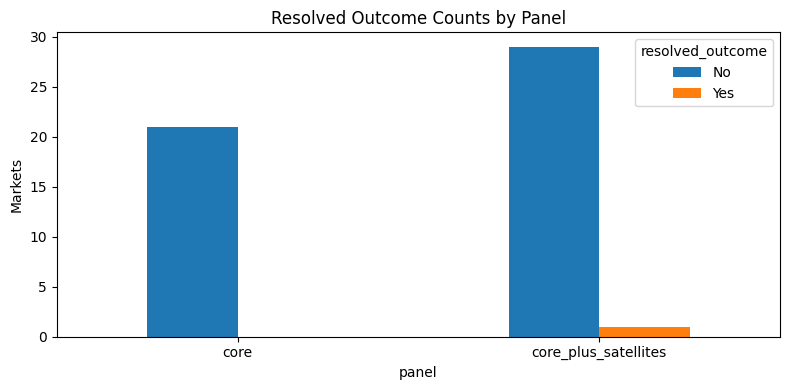

In [3]:
def panel_label_table(panel, panel_name):
    ids = set(panel.columns.astype(str))
    m = market_universe[market_universe["market_id"].isin(ids)].copy()
    return (
        m.groupby(["resolved_outcome", "market_family"], dropna=False)
        .size()
        .rename("markets")
        .reset_index()
        .assign(panel=panel_name)
    )

label_table = pd.concat([
    panel_label_table(core_panel, "core"),
    panel_label_table(core_plus_panel, "core_plus_satellites"),
], ignore_index=True)
display(label_table)

fig, ax = plt.subplots(figsize=(8, 4))
counts = label_table.groupby(["panel", "resolved_outcome"])["markets"].sum().unstack(fill_value=0)
counts.plot(kind="bar", ax=ax)
ax.set_title("Resolved Outcome Counts by Panel")
ax.set_ylabel("Markets")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Fold Definitions

In [4]:
fold_rows = []
for panel_name, panel in [("core", core_panel), ("core_plus_satellites", core_plus_panel)]:
    for fold in make_chronological_folds(panel):
        fold_rows.append({
            "panel": panel_name,
            "fold": fold.fold,
            "train_start": fold.train_start,
            "train_end": fold.train_end,
            "test_start": fold.test_start,
            "test_end": fold.test_end,
            "train_hours": int((panel.index <= fold.train_end).sum()),
            "test_hours": int(((panel.index >= fold.test_start) & (panel.index <= fold.test_end)).sum()),
        })
folds_df = pd.DataFrame(fold_rows)
display(folds_df)

,panel,fold,train_start,train_end,test_start,test_end,train_hours,test_hours
0,core,1,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,3417,336
1,core,2,2024-12-30 23:00:00+00:00,2025-10-12 09:00:00+00:00,2025-10-12 10:00:00+00:00,2025-10-26 09:00:00+00:00,3753,336
2,core,3,2024-12-30 23:00:00+00:00,2025-10-26 09:00:00+00:00,2025-10-26 10:00:00+00:00,2025-11-09 09:00:00+00:00,4089,336
3,core,4,2024-12-30 23:00:00+00:00,2025-11-09 09:00:00+00:00,2025-11-09 10:00:00+00:00,2025-11-23 09:00:00+00:00,4425,336
4,core,5,2024-12-30 23:00:00+00:00,2025-11-23 09:00:00+00:00,2025-11-23 10:00:00+00:00,2025-12-07 09:00:00+00:00,4761,336
5,core,6,2024-12-30 23:00:00+00:00,2025-12-07 09:00:00+00:00,2025-12-07 10:00:00+00:00,2025-12-21 09:00:00+00:00,5097,336
6,core,7,2024-12-30 23:00:00+00:00,2025-12-21 09:00:00+00:00,2025-12-21 10:00:00+00:00,2026-01-01 08:00:00+00:00,5433,263
7,core_plus_satellites,1,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,3417,336
8,core_plus_satellites,2,2024-12-30 23:00:00+00:00,2025-10-12 09:00:00+00:00,2025-10-12 10:00:00+00:00,2025-10-26 09:00:00+00:00,3753,336
9,core_plus_satellites,3,2024-12-30 23:00:00+00:00,2025-10-26 09:00:00+00:00,2025-10-26 10:00:00+00:00,2025-11-09 09:00:00+00:00,4089,336


## Run Backtest and Save Outputs

In [5]:
supervised_df, predictions_df, results_df, calibration_df = run_all(
    core_panel_path=core_panel_path,
    core_plus_panel_path=core_plus_panel_path,
    market_universe_path=market_universe_path,
    output_dir=PROCESSED,
    known_labels_only=False,
)

print("supervised dataset:", supervised_df.shape)
print("predictions:", predictions_df.shape)
print("results:", results_df.shape)
print("calibration:", calibration_df.shape)

for path in [
    PROCESSED / "pca_supervised_dataset.parquet",
    PROCESSED / "pca_supervised_forecast_results.csv",
    PROCESSED / "pca_supervised_predictions.parquet",
    PROCESSED / "pca_supervised_calibration_by_decile.csv",
]:
    print(path.name, path.exists(), f"{path.stat().st_size / 1_000_000:.2f} MB")

supervised dataset: (2385492, 24)
predictions: (446339, 25)
results: (98, 17)
calibration: (120, 7)
pca_supervised_dataset.parquet True 8.41 MB
pca_supervised_forecast_results.csv True 0.02 MB
pca_supervised_predictions.parquet True 3.47 MB
pca_supervised_calibration_by_decile.csv True 0.01 MB


## Data Integrity Checks

In [6]:
checks = {
    "supervised_rows": len(supervised_df),
    "prediction_rows": len(predictions_df),
    "results_rows": len(results_df),
    "p_i_t_outside_0_1": int((~supervised_df["p_i_t"].between(0, 1)).sum()) if len(supervised_df) else 0,
    "p_hat_outside_0_1": int((~predictions_df["p_hat"].between(0, 1)).sum()) if len(predictions_df) else 0,
    "supervised_inf_values": int(np.isinf(supervised_df.select_dtypes(include=[np.number])).sum().sum()) if len(supervised_df) else 0,
    "prediction_inf_values": int(np.isinf(predictions_df.select_dtypes(include=[np.number])).sum().sum()) if len(predictions_df) else 0,
    "supervised_nan_feature_cells": int(supervised_df.filter(regex=r"^(p_i_t|pca_)").isna().sum().sum()) if len(supervised_df) else 0,
    "prediction_nan_probability_cells": int(predictions_df[["p_i_t", "p_hat"]].isna().sum().sum()) if len(predictions_df) else 0,
}
checks

{'supervised_rows': 2385492,
 'prediction_rows': 446339,
 'results_rows': 98,
 'p_i_t_outside_0_1': 0,
 'p_hat_outside_0_1': 0,
 'supervised_inf_values': 0,
 'prediction_inf_values': 0,
 'supervised_nan_feature_cells': 6657816,
 'prediction_nan_probability_cells': 0}

## Forecast Results

In [7]:
ok_results = results_df[results_df["status"].eq("ok")].copy()
summary = (
    ok_results.groupby(["panel", "model"], as_index=False)
    .agg(
        folds=("fold", "nunique"),
        mean_components=("n_components", "mean"),
        mean_brier=("brier", "mean"),
        mean_log_loss=("log_loss", "mean"),
        total_obs=("n_obs", "sum"),
        avg_pred=("avg_pred", "mean"),
        avg_actual=("avg_actual", "mean"),
    )
    .sort_values(["panel", "mean_brier"])
)
display(summary)

skipped = results_df[~results_df["status"].eq("ok")]
if len(skipped):
    display(
        skipped.groupby(["panel", "model", "status"], as_index=False)
        .agg(folds=("fold", "nunique"), train_rows=("train_rows", "mean"), test_rows=("test_rows", "mean"))
    )

,panel,model,folds,mean_components,mean_brier,mean_log_loss,total_obs,avg_pred,avg_actual
0,core,market_probability,7,0.000000,0.021603,0.087295,38743,0.069140,0.000000
2,core_plus_satellites,fixed_2,7,2.000000,0.037044,0.157900,58228,0.035097,0.039253
6,core_plus_satellites,var_90,7,6.857143,0.037077,0.157811,58228,0.038750,0.039253
5,core_plus_satellites,var_85,7,5.571429,0.037099,0.157916,58228,0.037745,0.039253
3,core_plus_satellites,fixed_5,7,5.000000,0.037129,0.158132,58228,0.038504,0.039253
7,core_plus_satellites,var_95,7,9.428571,0.037224,0.159400,58228,0.042174,0.039253
1,core_plus_satellites,fixed_10,7,10.000000,0.037230,0.159467,58228,0.042131,0.039253
4,core_plus_satellites,market_probability,7,0.000000,0.040121,0.128542,58228,0.057560,0.039253


,panel,model,status,folds,train_rows,test_rows
0,core,fixed_10,skipped:single_class_train_labels,7,75058.0,5534.714286
1,core,fixed_2,skipped:single_class_train_labels,7,75058.0,5534.714286
2,core,fixed_5,skipped:single_class_train_labels,7,75058.0,5534.714286
3,core,var_85,skipped:single_class_train_labels,7,75058.0,5534.714286
4,core,var_90,skipped:single_class_train_labels,7,75058.0,5534.714286
5,core,var_95,skipped:single_class_train_labels,7,75058.0,5534.714286


## PCA Improvement vs Raw Market Probability

In [8]:
baseline = summary[summary["model"].eq("market_probability")][["panel", "mean_brier", "mean_log_loss"]].rename(
    columns={"mean_brier": "baseline_brier", "mean_log_loss": "baseline_log_loss"}
)
comparison = summary[~summary["model"].eq("market_probability")].merge(baseline, on="panel", how="left")
comparison["brier_improvement"] = comparison["baseline_brier"] - comparison["mean_brier"]
comparison["log_loss_improvement"] = comparison["baseline_log_loss"] - comparison["mean_log_loss"]
display(comparison.sort_values(["panel", "brier_improvement"], ascending=[True, False]))

,panel,model,folds,mean_components,mean_brier,mean_log_loss,total_obs,avg_pred,avg_actual,baseline_brier,baseline_log_loss,brier_improvement,log_loss_improvement
0,core_plus_satellites,fixed_2,7,2.000000,0.037044,0.157900,58228,0.035097,0.039253,0.040121,0.128542,0.003076,-0.029357
1,core_plus_satellites,var_90,7,6.857143,0.037077,0.157811,58228,0.038750,0.039253,0.040121,0.128542,0.003043,-0.029269
2,core_plus_satellites,var_85,7,5.571429,0.037099,0.157916,58228,0.037745,0.039253,0.040121,0.128542,0.003022,-0.029373
3,core_plus_satellites,fixed_5,7,5.000000,0.037129,0.158132,58228,0.038504,0.039253,0.040121,0.128542,0.002991,-0.029590
4,core_plus_satellites,var_95,7,9.428571,0.037224,0.159400,58228,0.042174,0.039253,0.040121,0.128542,0.002897,-0.030858
5,core_plus_satellites,fixed_10,7,10.000000,0.037230,0.159467,58228,0.042131,0.039253,0.040121,0.128542,0.002891,-0.030924


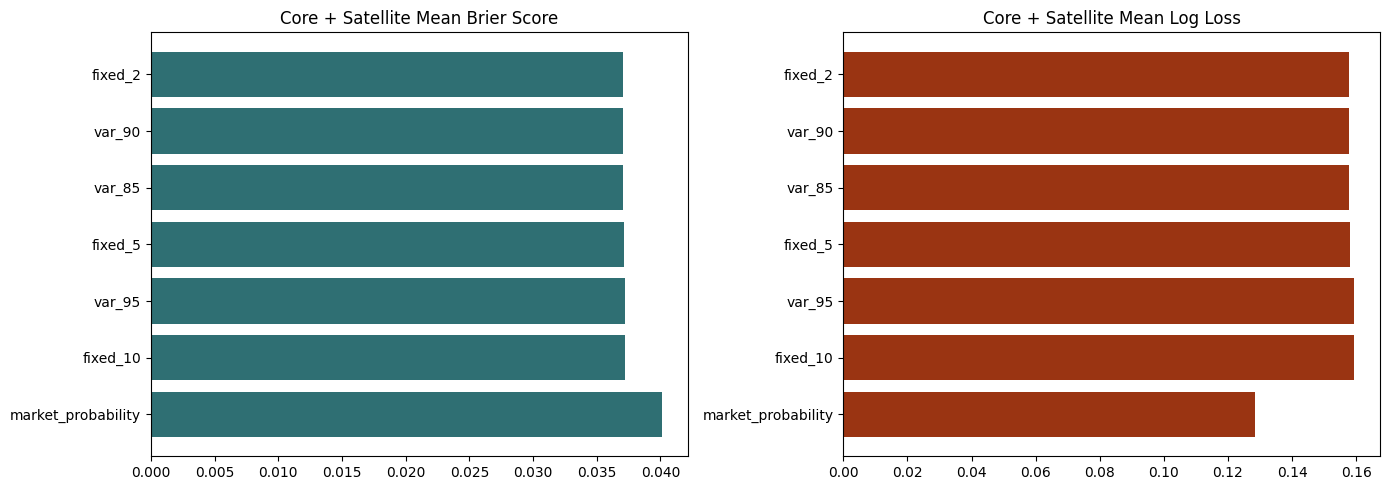

In [9]:
plot_df = summary[summary["panel"].eq("core_plus_satellites")].sort_values("mean_brier")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df["model"], plot_df["mean_brier"], color="#2f6f73")
axes[0].set_title("Core + Satellite Mean Brier Score")
axes[0].invert_yaxis()
axes[1].barh(plot_df["model"], plot_df["mean_log_loss"], color="#9a3412")
axes[1].set_title("Core + Satellite Mean Log Loss")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## Fold-by-Fold Performance

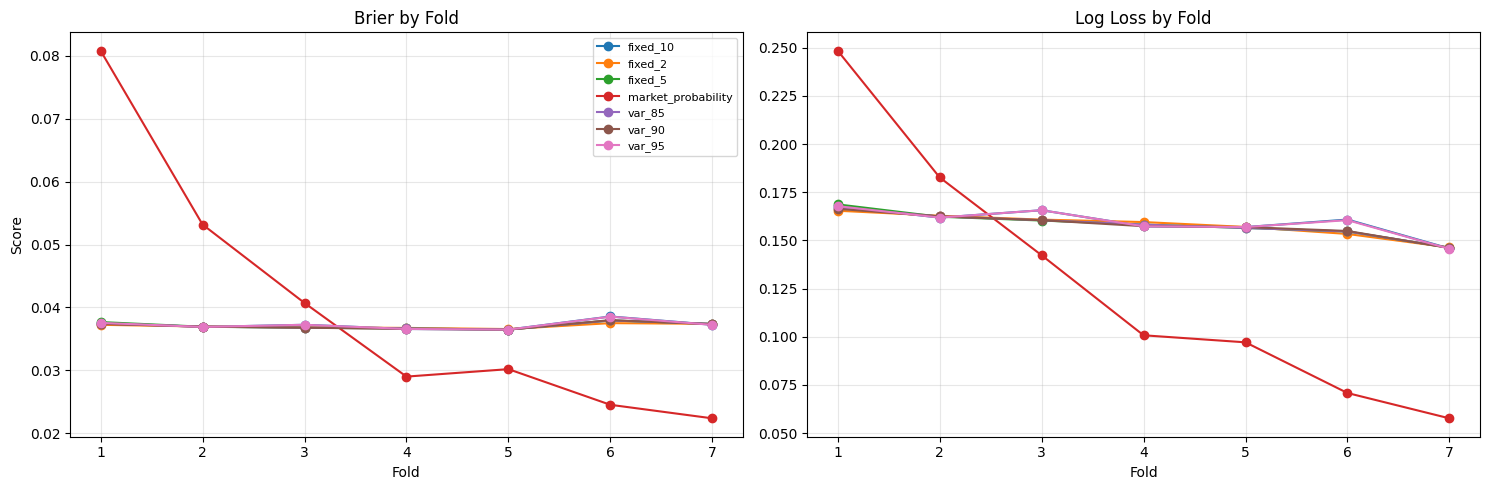

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plot_results = ok_results[ok_results["panel"].eq("core_plus_satellites")]
for model, group in plot_results.groupby("model"):
    group = group.sort_values("fold")
    axes[0].plot(group["fold"], group["brier"], marker="o", label=model)
    axes[1].plot(group["fold"], group["log_loss"], marker="o", label=model)
axes[0].set_title("Brier by Fold")
axes[1].set_title("Log Loss by Fold")
for ax in axes:
    ax.set_xlabel("Fold")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Calibration by Probability Decile

,model,prob_decile,n_obs,avg_pred,avg_actual
0,fixed_10,0,58131,0.042055,0.039298
1,fixed_10,1,97,0.107575,0.026316
2,fixed_2,0,58210,0.035080,0.039264
3,fixed_2,1,18,0.105232,0.000000
4,fixed_5,0,58076,0.038381,0.039334
5,fixed_5,1,152,0.109297,0.006579
6,market_probability,0,48142,0.019167,0.001284
7,market_probability,1,5425,0.151385,0.527238
8,market_probability,2,1907,0.238240,0.330219
9,market_probability,3,941,0.346049,0.333333


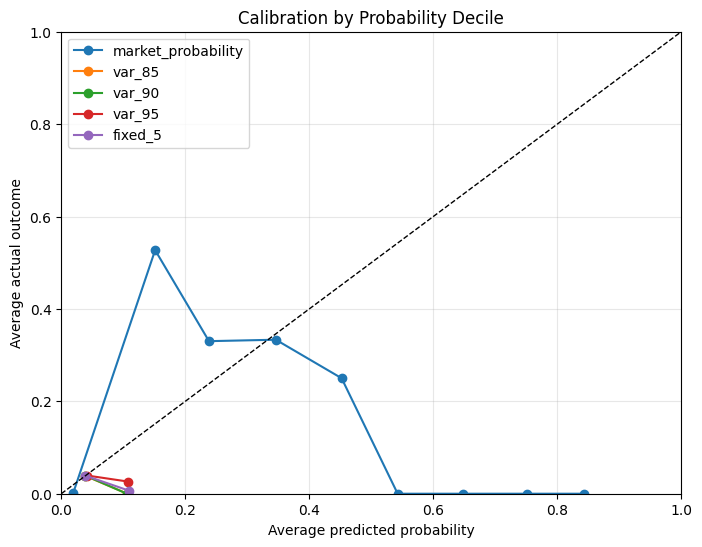

In [11]:
cal = calibration_df[calibration_df["panel"].eq("core_plus_satellites")].copy()
cal_summary = (
    cal.groupby(["model", "prob_decile"], as_index=False)
    .agg(n_obs=("n_obs", "sum"), avg_pred=("avg_pred", "mean"), avg_actual=("avg_actual", "mean"))
)
display(cal_summary.head(30))

fig, ax = plt.subplots(figsize=(8, 6))
for model in ["market_probability", "var_85", "var_90", "var_95", "fixed_5"]:
    sub = cal_summary[cal_summary["model"].eq(model)]
    if len(sub):
        ax.plot(sub["avg_pred"], sub["avg_actual"], marker="o", label=model)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_title("Calibration by Probability Decile")
ax.set_xlabel("Average predicted probability")
ax.set_ylabel("Average actual outcome")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Interpretation

- The raw market-implied probability baseline is very strong.
- The core-only supervised logistic model is not estimable because every retained core-panel market resolved `No`.
- On the core+satellite panel, PCA logistic models slightly improve Brier score versus raw market probability in this run, but they worsen log loss.
- The log-loss result means the PCA logistic model is less well calibrated in the tails, even if squared-error performance improves slightly.
- This is a useful baseline for the later topology comparison: persistent-homology features should be evaluated with the same fold design and the same logistic-regression downstream model.